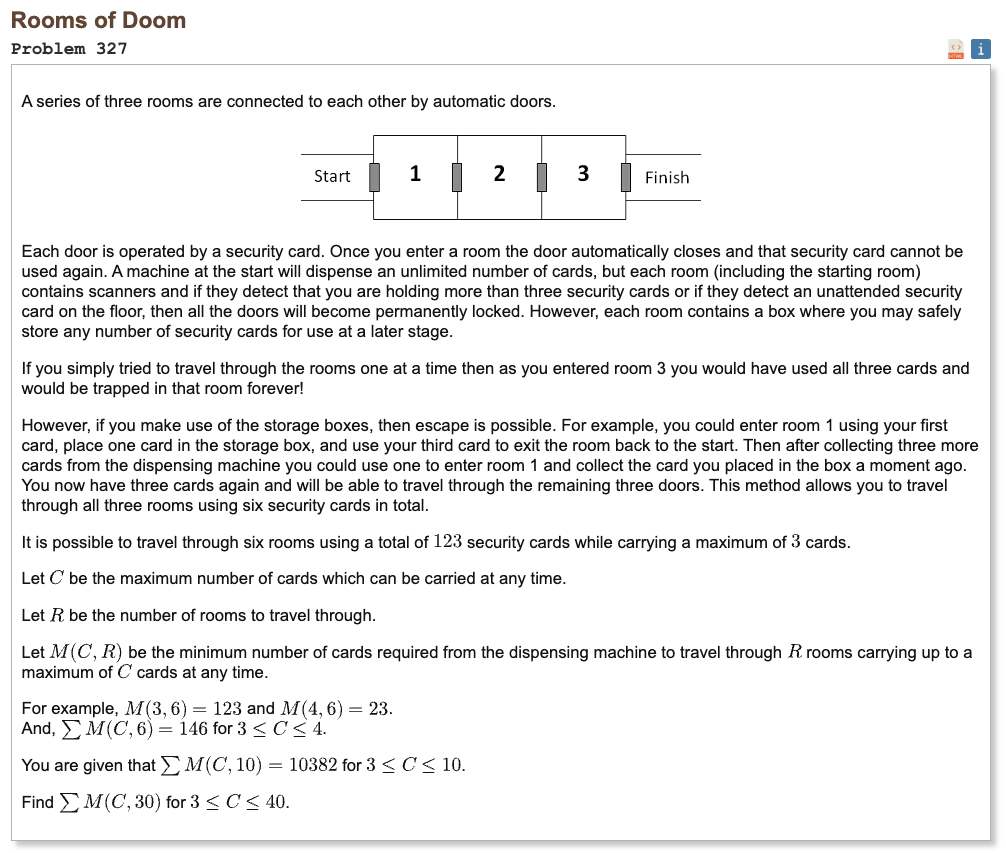

## Initial approach

* work from the exit backwards instead of simulating all movements
* the last room only needs one card to escape
* each room to the left must prepare enough cards for the rooms after it
* if the needed cards exceed the carry limit, extra shuttle trips are required
* each shuttle trip wastes two cards, one to enter and one to return
* process all rooms with this recurrence
* sum the result for all carry limits from 3 to 40

In [1]:
def M(cards, rooms):
    need = 1
    transport = cards - 2

    for _ in range(rooms):
        consumed = 0

        if need >= cards:
            moves = (need - cards) // transport

            if need - moves * transport >= cards:
                moves += 1

            need -= moves * transport
            consumed += moves * cards

        need = need + consumed + 1

    return need

def solve():
    return sum(M(cards, 30) for cards in range(3, 41))

assert M(3, 6) == 123
assert M(4, 6) == 23
assert sum(M(cards, 6) for cards in range(3, 5)) == 146
assert sum(M(cards, 10) for cards in range(3, 11)) == 10382

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 34315549139516
CPU times: user 196 μs, sys: 7 μs, total: 203 μs
Wall time: 200 μs
